<a href="https://www.kaggle.com/code/kushagraparashar005/notebook6b6f271148?scriptVersionId=331334135" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/kushagraparashar005/sms-spam-collection-dataset/sms_spam_collection (1).csv


In [3]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/kushagraparashar005/sms-spam-collection-dataset/sms_spam_collection (1).csv', encoding='latin-1')

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
df.columns

Index(['label', 'message'], dtype='object')

In [5]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/kushagraparashar005/sms-spam-collection-dataset/sms_spam_collection (1).csv')

print(df.columns)
print(df.head())

Index(['label', 'message'], dtype='object')
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [6]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/kushagraparashar005/sms-spam-collection-dataset/sms_spam_collection (1).csv')

# Rename columns if needed
if 'Category' in df.columns:
    df.rename(columns={'Category':'label', 'Message':'message'}, inplace=True)

print(df.columns)

# Convert labels
df['label'] = df['label'].map({'ham':0, 'spam':1})

# Remove missing values
df = df.dropna()

df.head()

Index(['label', 'message'], dtype='object')


,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
from sklearn.model_selection import train_test_split

X = df['message']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

X = df['message'].astype(str)
y = df['label']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

vectorizer = TfidfVectorizer(stop_words='english')

X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

In [9]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [10]:
msg = ["Congratulations! You won a free lottery worth Rs. 5,00,000. Click here now."]

msg_vector = vectorizer.transform(msg)
prediction = model.predict(msg_vector)

print("Spam" if prediction[0] == 1 else "Ham")

Spam


In [11]:
messages = [
    "Hey, are we meeting at 6 PM today?",
    "Congratulations! You won a free iPhone. Click here to claim.",
    "Your OTP is 482913. Do not share it with anyone.",
    "URGENT! You have won ₹1,00,000. Call now to claim your prize."
]

for msg in messages:
    prediction = model.predict(vectorizer.transform([msg]))
    result = "Spam" if prediction[0] == 1 else "Ham"
    print(f"Message: {msg}")
    print(f"Prediction: {result}\n")

Message: Hey, are we meeting at 6 PM today?
Prediction: Ham

Message: Congratulations! You won a free iPhone. Click here to claim.
Prediction: Spam

Message: Your OTP is 482913. Do not share it with anyone.
Prediction: Ham

Message: URGENT! You have won ₹1,00,000. Call now to claim your prize.
Prediction: Spam



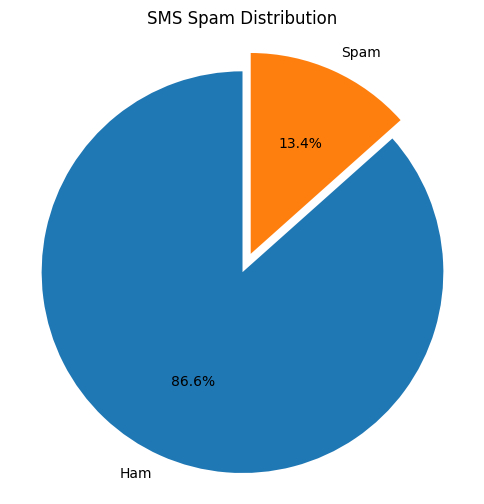

In [12]:
import matplotlib.pyplot as plt

# Count labels
counts = df['label'].value_counts()

# Rename labels for display
labels = ['Ham', 'Spam']

plt.figure(figsize=(6,6))
plt.pie(
    counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    explode=(0, 0.1)
)

plt.title("SMS Spam Distribution")
plt.axis('equal')  # Makes the pie chart circular
plt.show()

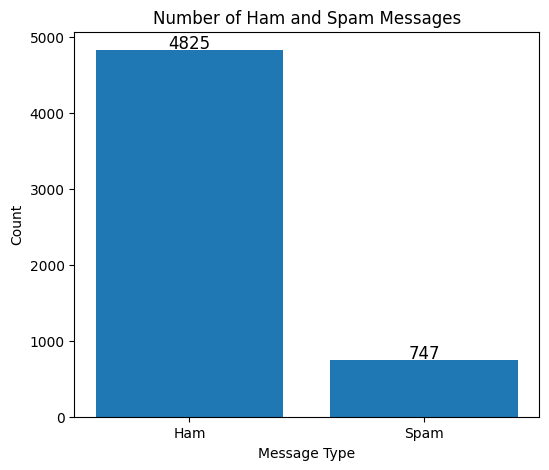

In [13]:
import matplotlib.pyplot as plt

# Count Ham and Spam messages
counts = df['label'].value_counts()

# Labels
labels = ['Ham', 'Spam']

# Create bar chart
plt.figure(figsize=(6,5))
plt.bar(labels, counts.values)

# Add values on top of bars
for i, value in enumerate(counts.values):
    plt.text(i, value + 20, str(value), ha='center', fontsize=12)

plt.title("Number of Ham and Spam Messages")
plt.xlabel("Message Type")
plt.ylabel("Count")

plt.show()

In [14]:
# Predict on the whole dataset
predictions = model.predict(vectorizer.transform(df['message']))

# Convert numeric predictions to labels
predictions = ['spam' if p == 1 else 'ham' for p in predictions]

# Create submission-like file
submission = df.copy()
submission['Predicted_Label'] = predictions

# Save CSV
submission.to_csv('submission.csv', index=False)

print(submission.head())

   label                                            message Predicted_Label
0      0  Go until jurong point, crazy.. Available only ...             ham
1      0                      Ok lar... Joking wif u oni...             ham
2      1  Free entry in 2 a wkly comp to win FA Cup fina...            spam
3      0  U dun say so early hor... U c already then say...             ham
4      0  Nah I don't think he goes to usf, he lives aro...             ham


In [15]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Load Dataset
df = pd.read_csv('/kaggle/input/datasets/kushagraparashar005/sms-spam-collection-dataset/sms_spam_collection (1).csv')

# Rename columns if needed
if 'Category' in df.columns:
    df.rename(columns={'Category':'label', 'Message':'message'}, inplace=True)

# Convert labels to numeric
df['label'] = df['label'].map({'ham':0, 'spam':1})

# Remove missing values
df = df.dropna()

# Features and target
X = df['message'].astype(str)
y = df['label']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# TF-IDF
vectorizer = TfidfVectorizer(stop_words='english')
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

# Train Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict on complete dataset
X_all = vectorizer.transform(df['message'])
predictions = model.predict(X_all)

# Convert numeric predictions back to labels
predictions = ['spam' if p == 1 else 'ham' for p in predictions]

# Create submission dataframe
submission = pd.DataFrame({
    'Message': df['message'],
    'Actual_Label': df['label'].map({0:'ham', 1:'spam'}),
    'Predicted_Label': predictions
})

# Save CSV
submission.to_csv('submission.csv', index=False)

print("submission.csv created successfully!")
print(submission.head())

submission.csv created successfully!
                                             Message Actual_Label  \
0  Go until jurong point, crazy.. Available only ...          ham   
1                      Ok lar... Joking wif u oni...          ham   
2  Free entry in 2 a wkly comp to win FA Cup fina...         spam   
3  U dun say so early hor... U c already then say...          ham   
4  Nah I don't think he goes to usf, he lives aro...          ham   

  Predicted_Label  
0             ham  
1             ham  
2            spam  
3             ham  
4             ham  
